# 🧠 Day 4 — Building & Training a Network in Keras
### 🏢 BinX Tech | AI & ML Internship — Week 6
### 🧠 Phase 3 · Sprint 1 · Deep Learning Intro

---

## 🎯 Today's Mission
> Days 1-3 covered the theory: neurons, layers, activations, forward propagation, loss,
> gradient descent, and backpropagation. Today we stop doing it by hand and let
> TensorFlow/Keras do the heavy lifting — build, compile, train, and evaluate a real network 🔥

| 🎓 Objective | 📌 Details |
|---|---|
| 1️⃣ | Build a neural network with the Keras Sequential API |
| 2️⃣ | Compile, train, and evaluate the network, and read its training history |
| 3️⃣ | Apply batch normalization and dropout to stabilize training and reduce overfitting |

---

## 🧪 Hands-On Lab Checklist
- [x] 1️⃣ Build a Keras Sequential network appropriate for the Phase 3 project task 🧱
- [x] 2️⃣ Compile with Adam and the right loss, train with a validation split for ≥30 epochs 🏋️
- [x] 3️⃣ Plot training vs. validation loss and accuracy, diagnose the fit 📈
- [x] 4️⃣ Add dropout and/or batch normalization and compare loss curves 🛡️
- [x] 5️⃣ Evaluate on the test set and compare the score to the Day 1 baseline 🏁

☕️ GPU on (Colab), coffee refilled — let's train our first network! 🚀

---
## 📦 Step 0 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

%matplotlib inline

print(f'✅ TensorFlow {tf.__version__} loaded — GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ TensorFlow 2.20.0 loaded — GPU available: False


---
## 📂 Step 1 — Load Data & Establish Train/Val/Test Splits

🔁 Same discipline as Weeks 4-5: scale the features, and split into train / validation / test
*before* touching the model. The validation set drives every tuning decision today; the test
set stays untouched until Step 6.

In [2]:
# 🔧 TODO: replace this with your real Phase 3 project dataset
# df = pd.read_csv('your_dataset.csv')

# 🎲 Demo binary-classification dataset (delete once you load your real data)
from sklearn.datasets import make_classification
X_demo, y_demo = make_classification(n_samples=800, n_features=12, n_informative=8,
                                      n_redundant=2, random_state=42)
df = pd.DataFrame(X_demo, columns=[f'feature_{i+1}' for i in range(X_demo.shape[1])])
df['target'] = y_demo

print(f'📊 Data shape: {df.shape[0]} rows × {df.shape[1]-1} features')
df.head()

📊 Data shape: 800 rows × 12 features


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,target
0,-2.521353,-3.214779,2.992398,-3.155482,6.873667,-0.739688,3.068086,-0.890794,-1.654182,1.486531,-4.317263,4.971402,1
1,-2.009509,-1.519932,-1.743609,0.053608,4.717155,-0.347291,0.886804,-0.960729,-0.448082,-1.658114,-2.760999,3.118500,1
2,-0.507775,-1.163786,2.806740,-2.396823,-3.655189,-2.779707,0.567198,-1.033206,1.383131,0.637731,0.901070,-2.335540,0
3,-3.225127,3.470885,0.989049,-4.942350,9.718176,0.152892,-2.891192,-0.770288,-0.879966,1.350646,-3.787961,1.364206,0
4,1.564591,0.646996,2.797294,-0.723405,0.575544,-0.641863,-0.099212,-1.764406,-1.293869,1.968784,-0.337822,0.639392,0


In [3]:
X = df.drop(columns=['target'])
y = df['target']

# 70/15/15 train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

n_features = X_train_s.shape[1]
print(f'✅ Train: {X_train_s.shape[0]} | Val: {X_val_s.shape[0]} | Test: {X_test_s.shape[0]} | Features: {n_features}')

✅ Train: 560 | Val: 120 | Test: 120 | Features: 12


---
## 🏁 Step 1b — Day 1 Baseline (for comparison later)

Per the program rule: *a neural network's score is meaningless without a baseline to beat.*
This re-trains the simple Day 1 baseline model on this exact split, so Step 6 has something
real to compare against.

In [4]:
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_s, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test_s))

print(f'🏁 Day 1 baseline (Logistic Regression) test accuracy: {baseline_acc:.4f}')
print('   ↳ Every network trained today must beat this number to be worth keeping.')

🏁 Day 1 baseline (Logistic Regression) test accuracy: 0.8667
   ↳ Every network trained today must beat this number to be worth keeping.


---
## 🧱 Step 2 — Build the Network (Keras Sequential API)

A Dense (fully connected) layer connects every input to every neuron. `input_shape` on
the first layer must match the number of features; the output layer's activation depends
on the task (sigmoid = binary classification).

In [5]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(n_features,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid'),   # binary output — TODO: change to softmax(n_classes) for multi-class
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

---
## ⚙️ Step 3 — Compile, Train, Evaluate

Same three-step workflow as Scikit-learn (Week 3): `compile()` sets the optimizer/loss/metrics,
`fit()` runs the training loop, `evaluate()` scores it on held-out data.

In [6]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_s, y_train,
                     validation_data=(X_val_s, y_val),
                     epochs=50, batch_size=32, verbose=0)

val_loss, val_acc = model.evaluate(X_val_s, y_val, verbose=0)
print(f'✅ Training done — final validation accuracy: {val_acc:.4f}, validation loss: {val_loss:.4f}')

✅ Training done — final validation accuracy: 0.9000, validation loss: 0.4066


---
## 📈 Step 4 — Read the Training History (Loss & Accuracy Curves)

The `history` object logs loss/accuracy per epoch for both train and validation.
Diagnose the fit exactly like Week 4: train ↓ + val ↑ = overfitting; both stuck high = underfitting.

/tmp/ipykernel_10607/2911601536.py:13: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_10607/2911601536.py:13: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


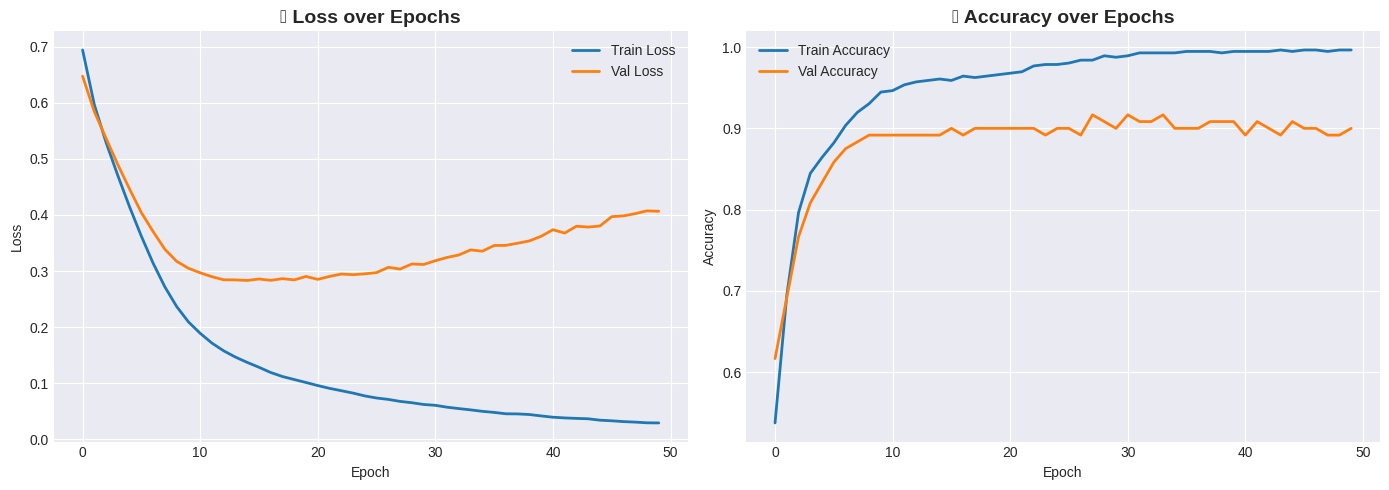

👀 Diagnose: is the gap between train and val growing (overfitting)? Flat and high (underfitting)? Or converging nicely?


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('📉 Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('📈 Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()

print('👀 Diagnose: is the gap between train and val growing (overfitting)? Flat and high (underfitting)? Or converging nicely?')

---
## 🛡️ Step 5 — Add Batch Normalization & Dropout

Two standard layers to stabilize training and fight overfitting:
- **BatchNormalization** — normalizes each layer's inputs, trains faster and more stably
- **Dropout** — randomly switches off a fraction of neurons each step (a regularizer, like Week 4's regularization)

/tmp/ipykernel_10607/2293873740.py:20: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_10607/2293873740.py:20: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


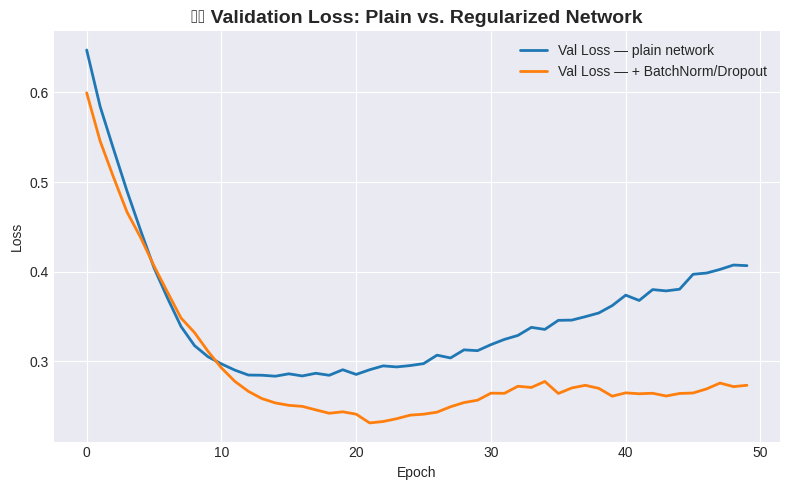

In [8]:
model_v2 = Sequential([
    Dense(64, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),                     # drop 30% of neurons each step
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model_v2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_v2 = model_v2.fit(X_train_s, y_train,
                           validation_data=(X_val_s, y_val),
                           epochs=50, batch_size=32, verbose=0)

plt.figure(figsize=(8, 5))
plt.plot(history.history['val_loss'], label='Val Loss — plain network', linewidth=2)
plt.plot(history_v2.history['val_loss'], label='Val Loss — + BatchNorm/Dropout', linewidth=2)
plt.title('🛡️ Validation Loss: Plain vs. Regularized Network')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

---
## 🏁 Step 6 — Final Evaluation vs. Day 1 Baseline

In [10]:
test_loss, test_acc = model_v2.evaluate(X_test_s, y_test, verbose=0)

print('📋 Final Comparison')
print(f'   🏁 Day 1 baseline (Logistic Regression): {baseline_acc:.4f}')
print(f'   🧠 Neural network (with BatchNorm/Dropout): {test_acc:.4f}')
beat = '✅ beats' if test_acc > baseline_acc else '⚠️ does NOT beat'
print(f'   → The network {beat} the baseline.')

📋 Final Comparison
   🏁 Day 1 baseline (Logistic Regression): 0.8667
   🧠 Neural network (with BatchNorm/Dropout): 0.9917
   → The network ✅ beats the baseline.


---
## ✅ Wrap-Up

| ✔️ You accomplished today |
|---|
| 🧱 Built a network with the Keras Sequential API |
| ⚙️ Compiled, trained, and evaluated it, and read the training history |
| 📈 Diagnosed the fit from the loss/accuracy curves |
| 🛡️ Applied BatchNormalization and Dropout and compared results |
| 🏁 Compared the tuned network to the Day 1 baseline |

🚀 **Up next (Day 5):** Systematic tuning, EarlyStopping, and the full Sprint 1 Review & Retrospective! 🔥